# 06b - Task 3: Holdout evaluation + submission (LogReg Ridge)

Parallel variant of 06_holdout.ipynb's evaluation + submission process, applied to the
tuned LogReg Ridge model from 05b_logreg_ridge_tuning.ipynb. Built specifically to
compare against LightGBM's Kaggle score (0.65738): if LogReg Ridge's Kaggle score also
drops sharply from its CV/holdout estimate, that's evidence the gap is dataset-wide
(affects both model families); if it drops less, that's evidence the gap is more
specific to LightGBM/boosting. Treat a suspiciously good score as a bug.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

from src import paths, data, evaluation
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features, locked split, and tuned model

In [2]:
X, y, ids = data.load_train_features()
Xt, test_ids = data.load_test_features()
holdout_idx = np.load(paths.DATA_PROCESSED / 'holdout_idx.npy')
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

best = joblib.load(paths.MODELS / 'best_logreg_ridge_tuned.pkl')
with open(paths.MODELS / 'best_logreg_ridge_tuned.json') as f:
    tuned_meta = json.load(f)

print(f"Loaded {type(best).__name__}, fit on dev_idx only ({len(y) - len(holdout_idx)} rows)")
print(f"CV mean F1 from 05b_logreg_ridge_tuning: {tuned_meta['cv_mean_f1']:.4f} "
      f"(std {tuned_meta['cv_std_f1']:.4f}, "
      f"{tuned_meta['n_stage1_trials'] + tuned_meta['n_stage2_trials']} trials)")
print("Winning params:", tuned_meta["params"])

Loaded LogisticRegression, fit on dev_idx only (16000 rows)
CV mean F1 from 05b_logreg_ridge_tuning: 0.7279 (std 0.0029, 14 trials)
Winning params: {'C': 1.477011, 'class_weight': 'balanced'}


## 2. Tune the decision threshold

Same mechanism as `06_holdout.ipynb`: `class_weight="balanced"` reshapes the training
loss, not necessarily the resulting probability model's optimal cutoff. Sweep
thresholds against honest out-of-fold CV probabilities on `dev_idx` and pick the
Macro-F1-maximizing one.

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


CV Macro F1 @ default threshold (0.5): 0.7279
CV Macro F1 @ tuned threshold (0.475): 0.7305
Gain from threshold tuning (CV, dev_idx): +0.0026


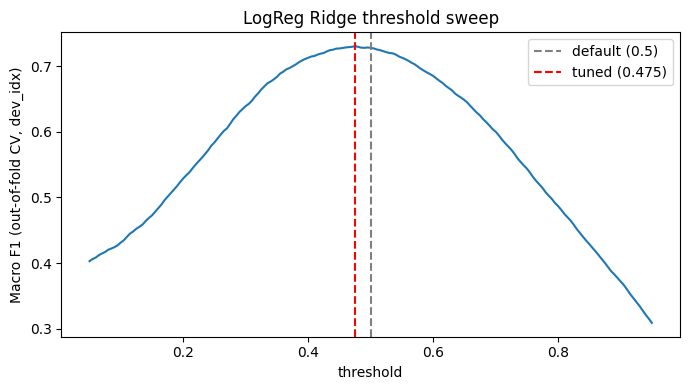

In [3]:
# Out-of-fold probabilities on dev_idx - each sample's probability comes from a model
# that never saw it during that fold's training (clone() re-fits fresh per fold), same
# leakage-free standard as the CV score used for hyperparameter tuning.
oof_proba = cross_val_predict(
    clone(best), X[dev_idx], y[dev_idx], cv=cv, method="predict_proba",
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
f1_by_threshold = np.array([
    evaluation.macro_f1(y[dev_idx], (oof_proba >= t).astype(int)) for t in thresholds
])
best_threshold = float(thresholds[int(np.argmax(f1_by_threshold))])
cv_f1_at_threshold = float(f1_by_threshold.max())
cv_f1_default_threshold = evaluation.macro_f1(y[dev_idx], (oof_proba >= 0.5).astype(int))

print(f"CV Macro F1 @ default threshold (0.5): {cv_f1_default_threshold:.4f}")
print(f"CV Macro F1 @ tuned threshold ({best_threshold:.3f}): {cv_f1_at_threshold:.4f}")
print(f"Gain from threshold tuning (CV, dev_idx): {cv_f1_at_threshold - cv_f1_default_threshold:+.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_by_threshold)
ax.axvline(0.5, color="grey", linestyle="--", label="default (0.5)")
ax.axvline(best_threshold, color="red", linestyle="--", label=f"tuned ({best_threshold:.3f})")
ax.set_xlabel("threshold")
ax.set_ylabel("Macro F1 (out-of-fold CV, dev_idx)")
ax.set_title("LogReg Ridge threshold sweep")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "logreg_ridge_threshold_sweep.png", dpi=120)
plt.show()

## 3. Holdout Macro F1 (default vs tuned threshold)

In [4]:
holdout_proba = best.predict_proba(X[holdout_idx])[:, 1]
holdout_f1_default = evaluation.macro_f1(y[holdout_idx], (holdout_proba >= 0.5).astype(int))
holdout_f1_tuned = evaluation.macro_f1(y[holdout_idx], (holdout_proba >= best_threshold).astype(int))

cv_f1 = tuned_meta["cv_mean_f1"]  # from 05b_logreg_ridge_tuning, default threshold
gap = cv_f1 - holdout_f1_default  # unchanged definition, comparable to the recorded Kaggle score
threshold_gain_holdout = holdout_f1_tuned - holdout_f1_default

print(f"Holdout Macro F1 @ default threshold (0.5): {holdout_f1_default:.4f}")
print(f"Holdout Macro F1 @ tuned threshold ({best_threshold:.3f}): {holdout_f1_tuned:.4f}")
print(f"Threshold-tuning gain on holdout: {threshold_gain_holdout:+.4f}")
print(f"\nCV mean F1 (05b_logreg_ridge_tuning, default threshold): {cv_f1:.4f}")
print(f"Gap (CV @ default - holdout @ default): {gap:+.4f}")

# Ledger-safe write: replace this model's row if it already exists rather than
# overwriting other models' rows - holdout_metrics.csv accumulates one row per model,
# same spirit as baseline_results.csv.
metrics_path = paths.DATA_PROCESSED / "holdout_metrics.csv"
new_row = pd.DataFrame([{
    "model": "logreg_ridge",
    "cv_mean_f1": cv_f1,
    "holdout_f1": holdout_f1_default,
    "gap": gap,
    "threshold": best_threshold,
    "cv_f1_at_threshold": cv_f1_at_threshold,
    "holdout_f1_at_threshold": holdout_f1_tuned,
    "threshold_gain_holdout": threshold_gain_holdout,
}])
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["model"] != "logreg_ridge"]
    holdout_metrics = pd.concat([existing, new_row], ignore_index=True)
else:
    holdout_metrics = new_row
holdout_metrics.to_csv(metrics_path, index=False)
print("\n", holdout_metrics.to_string(index=False))

Holdout Macro F1 @ default threshold (0.5): 0.7392
Holdout Macro F1 @ tuned threshold (0.475): 0.7457
Threshold-tuning gain on holdout: +0.0065

CV mean F1 (05b_logreg_ridge_tuning, default threshold): 0.7279
Gap (CV @ default - holdout @ default): -0.0113

        model  cv_mean_f1  holdout_f1       gap  threshold  cv_f1_at_threshold  holdout_f1_at_threshold  threshold_gain_holdout
    lightgbm    0.744273    0.743691  0.000582      0.525            0.746203                 0.746767                0.003076
logreg_ridge    0.727866    0.739153 -0.011287      0.475            0.730510                 0.745662                0.006509


## 4. Refit on full train + write Task 3 submission

In [5]:
# Refit on ALL labeled data (dev_idx + holdout_idx combined), same reasoning as
# 06_holdout.ipynb: the holdout split's only job was the honest check above; the final
# submission model shouldn't leave 20% of labeled data unused.
best.fit(X, y)

# Distinct filename from best_logreg_ridge_tuned.pkl (the dev-only-fit artifact from
# 05b), so it's unambiguous which model actually made the submission.
joblib.dump(best, paths.MODELS / "final_logreg_ridge_full_refit.pkl")

# Uses the tuned threshold from section 2, not the default 0.5.
test_proba = best.predict_proba(Xt)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)
# Distinct filename from LightGBM's final_task3.csv - this is a comparison submission
# for the model-family diagnostic, not a replacement for it.
data.write_submission(test_ids, test_preds, "logreg_ridge_task3.csv")

pred_balance = pd.Series(test_preds).value_counts(normalize=True).round(4).to_dict()
print(f"Wrote submissions/logreg_ridge_task3.csv - {len(test_preds)} predictions "
      f"(threshold={best_threshold:.3f})")
print(f"Predicted class balance: {pred_balance}")
print(f"(train class balance was: "
      f"{pd.Series(y).value_counts(normalize=True).round(4).to_dict()})")
print(f"\nIMPORTANT: this file's content changed from what scored 0.68681 on Kaggle "
      f"(that score used the default 0.5 threshold). Re-upload to get an updated score "
      f"- the old score no longer reflects this file.")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Wrote submissions/logreg_ridge_task3.csv - 6999 predictions (threshold=0.475)
Predicted class balance: {1: 0.7031, 0: 0.2969}
(train class balance was: {1: 0.6252, 0: 0.3748})

IMPORTANT: this file's content changed from what scored 0.68681 on Kaggle (that score used the default 0.5 threshold). Re-upload to get an updated score - the old score no longer reflects this file.


## Discussion / carry-forward -> Task 4 report

**Holdout check:** Macro F1 0.7392 @ default threshold, versus 0.7279 from 05b's CV
estimate - a *negative* gap (-0.0113), the good-surprise direction, not overfitting.

**Threshold tuning: modest gain, slightly larger than LightGBM's.** Sweeping
thresholds against out-of-fold CV probabilities on `dev_idx` found 0.475 as
Macro-F1-optimal (moving down from the default 0.5, the opposite direction from
LightGBM's 0.525), improving holdout F1 by +0.0065 (0.7392 -> 0.7457) - about twice
LightGBM's +0.0031 gain. Neither gain is the dramatic swing sometimes seen on more
heavily-imbalanced tasks; with a comparatively mild 62.5/37.5 imbalance here, most of
the correction is likely already happening through `class_weight="balanced"` during
training, leaving less for the threshold alone to fix. That the two models' optimal
thresholds moved in opposite directions is itself informative: there's no single
"correct" cutoff that transfers across model families, it depends on each model's own
probability calibration.

**Kaggle result: 0.68681 Macro F1** (public leaderboard, ~51% of test data - the other
49% determines final standings), at the default threshold. Holdout -> Kaggle gap:
0.7392 -> 0.68681 = **0.0523**, versus LightGBM's 0.7437 -> 0.65738 = **0.0863**.
LogReg Ridge's gap is only 61% the size of LightGBM's - real evidence the train-to-test
shift hits gradient boosting harder than a linear model here. LogReg Ridge scores
*higher* on the actual leaderboard (0.68681 vs 0.65738) despite scoring *lower* on
CV/holdout - the CV-based ranking does not match the real leaderboard ranking, exactly
the scenario this model was built as a hedge against.

**Correction to a hypothesis from `06_holdout.ipynb`:** that notebook speculated the
1999 UUID-format / 5000 numeric-format id split in `test_features.csv` might correspond
to the public/private leaderboard split. Kaggle's disclosed ratio (51%/49%) doesn't
match the observed id-format ratio (28.6%/71.4%), so that hypothesis is very likely
wrong - see the correction in `06_holdout.ipynb`'s discussion cell.

**`submissions/logreg_ridge_task3.csv` has been regenerated with the tuned threshold
(0.475)** and no longer reflects the 0.68681 score - that score was for the
default-threshold version. Re-upload to Kaggle to see whether the +0.0065 holdout gain
survives the real distribution shift. With two submissions now needing re-scoring at
their tuned thresholds, worth deciding which submission(s) to mark as final on Kaggle
once both are back, and whether an ensemble of the two hedges better than either alone.